In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_parquet("../data/processed/ml_daily_features.parquet")

# ensuring date is DATETIME and year is INT
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["year"].astype(int)

df.head()
df.dtypes


site_id                    object
site_name                  object
pollutant                  object
unit                       object
date               datetime64[ns]
year                        int64
daily_median              float64
daily_mean                float64
roll7                     float64
roll30                    float64
norm_median               float64
delta_abs                 float64
delta_pct                 float64
z                         float64
exceed_pm25_who             int64
exceed_pm10_who             int64
dtype: object

In [38]:
def eval_forecast(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

In [2]:
df["pollutant"] = (
    df["pollutant"]
    .str.upper()
    .str.replace(" ", "")
    .str.replace(".", "")
)

In [3]:
df_pm25 = df[df["pollutant"] == "PM25"].copy()

df_pm25.shape
df_pm25["site_id"].nunique(), df_pm25["site_name"].nunique()

(18, 17)

In [4]:
df_pm25['site_name'].unique()
df_pm25.columns

Index(['site_id', 'site_name', 'pollutant', 'unit', 'date', 'year',
       'daily_median', 'daily_mean', 'roll7', 'roll30', 'norm_median',
       'delta_abs', 'delta_pct', 'z', 'exceed_pm25_who', 'exceed_pm10_who'],
      dtype='object')

In [5]:
# For each row, check: "is my (site_id, pollutant) group all missing in norm_median?"
all_missing_groups = (
    df_pm25
    .groupby(["site_id", "pollutant"])["norm_median"]
    .transform(lambda s: s.isna().all())
)

# Keep only groups that have at least one valid norm_median
df_pm25 = df_pm25[~all_missing_groups].copy()   

In [6]:
# Implement missing value logic, only on the PM2.5 subset
df_pm25["z_missing"] = df_pm25["z"].isna().astype(int)
df_pm25["delta_pct_missing"] = df_pm25["delta_pct"].isna().astype(int)
df_pm25["norm_missing"] = df_pm25["norm_median"].isna().astype(int)
df_pm25["roll30_missing"] = df_pm25["roll30"].isna().astype(int)

# Impute
# z: treat missing values as "no surprise"
df_pm25["z"] = df_pm25["z"].fillna(0)

# delta_pct: missing when norm_median == 0 -> treat as 0% change
df_pm25["delta_pct"] = df_pm25["delta_pct"].fillna(0)

# norm_median: fill with median norm for that site and pollutant
df_pm25["norm_median"] = (
    df_pm25
    .groupby(["site_id", "pollutant"])["norm_median"]
    .transform(lambda s: s.fillna(s.median()))
)

# delta_abs: recompute from daily_median - norm_median (this method is safer than filling directly)
df_pm25["delta_abs"] = df_pm25["daily_median"] - df_pm25["norm_median"]

# roll30: where missing, fall back to roll7
df_pm25["roll30"] = df_pm25["roll30"].fillna(df_pm25["roll7"])

In [7]:
df_pm25.isna().mean().sort_values(ascending=False).head(10)

site_id         0.0
site_name       0.0
pollutant       0.0
unit            0.0
date            0.0
year            0.0
daily_median    0.0
daily_mean      0.0
roll7           0.0
roll30          0.0
dtype: float64

In [8]:
df_pm25.head(5)
df_pm25.describe()[["daily_median", "norm_median", "delta_abs", "roll7", "roll30"]]

,daily_median,norm_median,delta_abs,roll7,roll30
count,11747.000000,11747.000000,11747.000000,11747.000000,11747.000000
mean,6.758100,6.183177,0.574923,6.077445,5.773788
min,0.800000,1.304000,-83.395002,2.133500,2.631500
25%,4.100000,4.489125,-0.884250,4.533500,4.791000
50%,5.550000,5.698000,0.000000,5.592000,5.550000
75%,7.618250,7.236500,0.952250,6.950000,6.525000
max,253.450005,122.100001,244.783505,60.949999,14.500000
std,8.561846,3.440140,7.269799,2.859964,1.475622


In [9]:
# This section is to create lag features per site_id

# make sure the frame is sorted by site and date
df_pm25 = df_pm25.sort_values(["site_id", "date"]).reset_index(drop=True)


lag_source_cols = ["daily_median", "roll7", "roll30", "norm_median", "delta_abs"]
max_lag = 3

for col in lag_source_cols:
    for lag in range(1, max_lag + 1):
        new_col = f"{col}_lag{lag}"
        df_pm25[new_col] = (    
            df_pm25
            .groupby("site_id")[col]
            .shift(lag)
        )

# quick check of new columns
[c for c in df_pm25.columns if "lag" in c], df_pm25.shape

(['daily_median_lag1',
  'daily_median_lag2',
  'daily_median_lag3',
  'roll7_lag1',
  'roll7_lag2',
  'roll7_lag3',
  'roll30_lag1',
  'roll30_lag2',
  'roll30_lag3',
  'norm_median_lag1',
  'norm_median_lag2',
  'norm_median_lag3',
  'delta_abs_lag1',
  'delta_abs_lag2',
  'delta_abs_lag3'],
 (11747, 35))

In [10]:
# drop rows with missing lag values

lag_cols = [c for c in df_pm25.columns if "lag" in c]

df_lagged = df_pm25.dropna(subset=lag_cols).reset_index(drop=True)

df_lagged.shape, df_pm25.shape

((11696, 35), (11747, 35))

In [11]:
df_lagged[lag_cols].isna().sum()

daily_median_lag1    0
daily_median_lag2    0
daily_median_lag3    0
roll7_lag1           0
roll7_lag2           0
roll7_lag3           0
roll30_lag1          0
roll30_lag2          0
roll30_lag3          0
norm_median_lag1     0
norm_median_lag2     0
norm_median_lag3     0
delta_abs_lag1       0
delta_abs_lag2       0
delta_abs_lag3       0
dtype: int64

In [12]:
# making sure doy exists on the lagged frame
if "doy" not in df_lagged.columns:
    df_lagged["doy"] = df_lagged["date"].dt.dayofyear

In [15]:
# Make sure date is datetime
df_pm25["date"] = pd.to_datetime(df_pm25["date"])

# Ensure doy exists
if "doy" not in df_pm25.columns:
    df_pm25["doy"] = df_pm25["date"].dt.dayofyear

In [18]:
# building the list of sites
sites = df_pm25["site_name"].unique()

# done to store evaluation results later
site_results = []

# base features we will use
base_features = ["roll7", "roll30", "norm_median", "doy"]

# include lag features (lag1-lag3) for selected features
lag_features = [c for c in df_pm25.columns if "_lag" in c]

all_features = base_features + lag_features

site_results = []
site_metrics = []

for site in sites:
    print(f"\n=== Processing site: {site} ===")

    # subset the dataframe for the site
    df_site = df_pm25[df_pm25["site_name"] == site].copy()

    # drop rows that have NA in lag features
    df_site = df_site.dropna(subset=lag_features)

    # ensure sorted by date
    df_site = df_site.sort_values("date").reset_index(drop=True)

    # if too few rows, skip this site
    if len(df_site) < 150:
        print(f"  Skipping {site}: only {len(df_site)} rows after lag drop.")
        site_results.append({
            "site": site,
            "n_rows": len(df_site),
            "status": "too few rows",
        })
        continue

    # extract X and y
    X = df_site[all_features]
    y = df_site["daily_median"]

    # time-aware split
    split_idx = int(0.8 * len(df_site))
    X_train = X.iloc[:split_idx]
    X_test  = X.iloc[split_idx:]
    y_train = y.iloc[:split_idx]
    y_test  = y.iloc[split_idx:]

    # Baseline model: "yesterday = today"
    # uses daily_median_lag1 as prediction
    y_pred_naive = df_site["daily_median_lag1"].iloc[split_idx:]

    mae_naive = mean_absolute_error(y_test, y_pred_naive)
    rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
    r2_naive = r2_score(y_test, y_pred_naive)

    # Model A: Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    pred_lr = lr.predict(X_test)

    mae_lr = mean_absolute_error(y_test, pred_lr)
    rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
    r2_lr = r2_score(y_test, pred_lr)

    # Model B: Random Forest
    rf = RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=5,
    )
    rf.fit(X_train, y_train)
    pred_rf = rf.predict(X_test)

    mae_rf = mean_absolute_error(y_test, pred_rf)
    rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
    r2_rf   = r2_score(y_test, pred_rf)

    # store basic info
    site_results.append({
        "site": site,
        "n_rows": len(df_site),
        "n_train": len(X_train),
        "n_test": len(X_test),
        "status": "ok",
    })

    # store metrics
    site_metrics.append({
        "site": site,
        "mae_naive": mae_naive,
        "rmse_naive": rmse_naive,
        "r2_naive": r2_naive,
        "mae_lr": mae_lr,
        "rmse_lr": rmse_lr,
        "r2_lr": r2_lr,
        "mae_rf": mae_rf,
        "rmse_rf": rmse_rf,
        "r2_rf": r2_rf,
    })

    


=== Processing site: Alphington ===

=== Processing site: Footscray ===

=== Processing site: Brighton ===

=== Processing site: Traralgon ===

=== Processing site: Morwell East ===

=== Processing site: Dandenong ===

=== Processing site: Box Hill ===

=== Processing site: Geelong South ===

=== Processing site: Melton ===

=== Processing site: Morwell South ===

=== Processing site: Moe ===

=== Processing site: Churchill ===

=== Processing site: Melbourne CBD ===

=== Processing site: Newborough ===

=== Processing site: Campbellfield ===
  Skipping Campbellfield: only 69 rows after lag drop.

=== Processing site: Bendigo ===


In [39]:
test_frac = 0.2
arima_order = (3, 1, 1)
sarima_order = (2, 1, 2)
sarima_seasonal = (1, 0, 1, 7) # weekly seasonality

# features for XGBoost: all lag features + a few base ones
lag_cols_all = [c for c in df_lagged.columns if "lag" in c]
base_xgb_features = ["roll7", "roll30", "norm_median", "delta_abs", "doy"]
xgb_features = base_xgb_features + lag_cols_all

In [ ]:
all_site_metrics = []

In [19]:
metrics_df = pd.DataFrame(site_metrics)
metrics_df.head()

,site,mae_naive,rmse_naive,r2_naive,mae_lr,rmse_lr,r2_lr,mae_rf,rmse_rf,r2_rf
0,Alphington,2.880341,4.330489,0.227542,2.434650,3.713510,0.431971,2.615731,3.923123,0.366036
1,Footscray,2.189387,2.832217,0.068136,1.730489,2.293420,0.388965,1.187905,1.657013,0.681029
2,Brighton,2.335353,3.156316,-0.020021,1.933129,2.696456,0.255552,2.041748,2.823378,0.183820
3,Traralgon,1.947372,2.898675,-0.044243,2.056770,2.773763,0.043817,2.046385,3.553412,-0.569256
4,Morwell East,2.274945,2.885655,-1.027408,7.397277,21.074800,-107.138212,12.288432,24.754277,-148.194485


In [21]:
metrics_df.describe()[["mae_naive", "mae_lr", "mae_rf", 
                       "r2_naive", "r2_lr", "r2_rf"]]

,mae_naive,mae_lr,mae_rf,r2_naive,r2_lr,r2_rf
count,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000
mean,1.998087,2.387706,2.354765,-0.145623,-7.414067,-9.852062
std,0.500193,1.704116,2.811047,0.318535,27.608307,38.275453
min,1.173038,0.284621,0.335804,-1.027408,-107.138212,-148.194485
25%,1.675990,1.596288,1.306504,-0.217027,-0.573663,-0.302101
50%,1.947372,1.933129,1.703668,-0.066856,0.066707,0.083705
75%,2.359503,2.464056,2.134971,0.024058,0.322258,0.346787
max,2.880341,7.397277,12.288432,0.227542,0.867129,0.819156


In [22]:
# looking at which sites do best or worst
metrics_df.sort_values("r2_rf", ascending=False).head(10)
metrics_df.sort_values("r2_rf").head(10)

,site,mae_naive,rmse_naive,r2_naive,mae_lr,rmse_lr,r2_lr,mae_rf,rmse_rf,r2_rf
4,Morwell East,2.274945,2.885655,-1.027408,7.397277,21.074800,-107.138212,12.288432,24.754277,-148.194485
13,Newborough,1.646336,2.112601,-0.540747,0.872446,1.931728,-0.288216,1.071762,2.628192,-1.384574
11,Churchill,2.383653,3.150072,-0.036606,4.485639,5.749345,-2.453103,2.223556,4.064003,-0.725365
3,Traralgon,1.947372,2.898675,-0.044243,2.056770,2.773763,0.043817,2.046385,3.553412,-0.569256
5,Dandenong,1.726581,2.292061,-0.080166,1.621117,2.130541,0.066707,1.703668,2.243571,-0.034946
8,Melton,1.851210,2.445738,-0.297617,1.571458,2.042998,0.094554,1.646884,2.180636,-0.031557
6,Box Hill,1.705644,2.523549,0.070679,1.505064,2.289793,0.234871,1.789907,2.644877,-0.020830
7,Geelong South,1.570119,2.126170,-0.128351,1.768285,2.316904,-0.339875,1.425103,1.915991,0.083705
2,Brighton,2.335353,3.156316,-0.020021,1.933129,2.696456,0.255552,2.041748,2.823378,0.183820
12,Melbourne CBD,2.383941,3.490217,0.210615,2.171201,3.069776,0.389343,2.373999,3.477412,0.216397


In [46]:
# define X (features) and y (target)

base_feature_cols = ["roll7", "roll30", "norm_median", "doy"]
lag_cols = [c for c in df_lagged.columns if "lag" in c] 

feature_cols = base_feature_cols + lag_cols

X = df_lagged[feature_cols]
y = df_lagged["daily_median"]

X.shape, y.shape

((11696, 19), (11696,))

In [47]:
df_lagged.columns.tolist()

['site_id',
 'site_name',
 'pollutant',
 'unit',
 'date',
 'year',
 'daily_median',
 'daily_mean',
 'roll7',
 'roll30',
 'norm_median',
 'delta_abs',
 'delta_pct',
 'z',
 'exceed_pm25_who',
 'exceed_pm10_who',
 'z_missing',
 'delta_pct_missing',
 'norm_missing',
 'roll30_missing',
 'daily_median_lag1',
 'daily_median_lag2',
 'daily_median_lag3',
 'roll7_lag1',
 'roll7_lag2',
 'roll7_lag3',
 'roll30_lag1',
 'roll30_lag2',
 'roll30_lag3',
 'norm_median_lag1',
 'norm_median_lag2',
 'norm_median_lag3',
 'delta_abs_lag1',
 'delta_abs_lag2',
 'delta_abs_lag3',
 'doy']

In [48]:
# time aware train-test split

# ensure sorted by date
df_lagged = df_lagged.sort_values(["date", "site_id"]).reset_index(drop=True)

X = df_lagged[feature_cols]
y = df_lagged["daily_median"]

split_idx = int(len(df_lagged) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

len(X_train), len(X_test)


(9356, 2340)

In [49]:
# Training and evaluation - Model A: Linear regression with lag features
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)

mae_lr, rmse_lr, r2_lr


(2.635622861952213, np.float64(3.761970754121718), -0.02741539713305774)

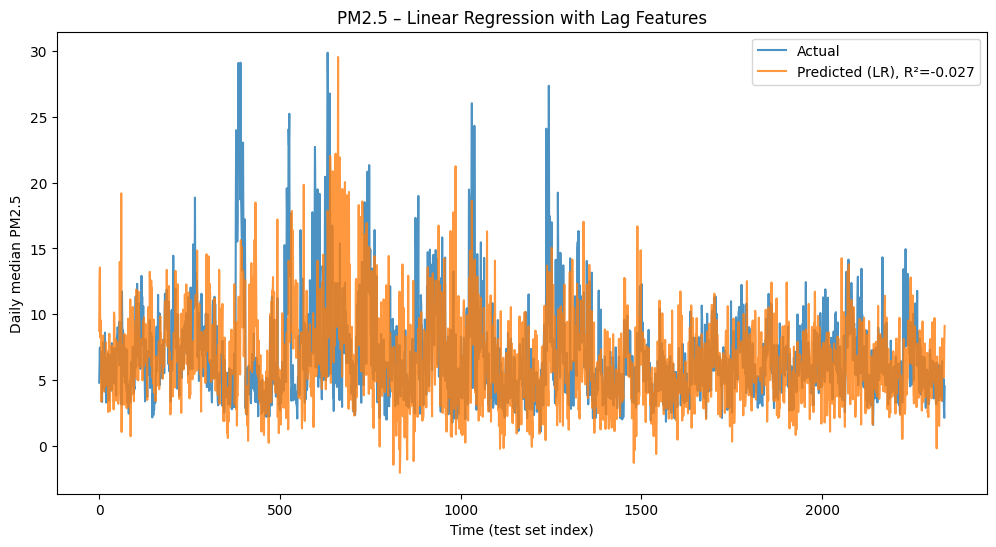

In [50]:
# plot for linear regression
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual", alpha=0.8)
plt.plot(pred_lr,       label=f"Predicted (LR), R²={r2_lr:.3f}", alpha=0.8)
plt.legend()
plt.title("PM2.5 – Linear Regression with Lag Features")
plt.xlabel("Time (test set index)")
plt.ylabel("Daily median PM2.5")
plt.show()

In [51]:
# Training and evaluation - Model B: Random Forest regressor with same lag features

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    min_samples_leaf=5, # small regularization to reduce overfitting
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf   = r2_score(y_test, pred_rf)

mae_rf, rmse_rf, r2_rf

(2.335866627776775, np.float64(3.7745901285314045), -0.034319802438499414)

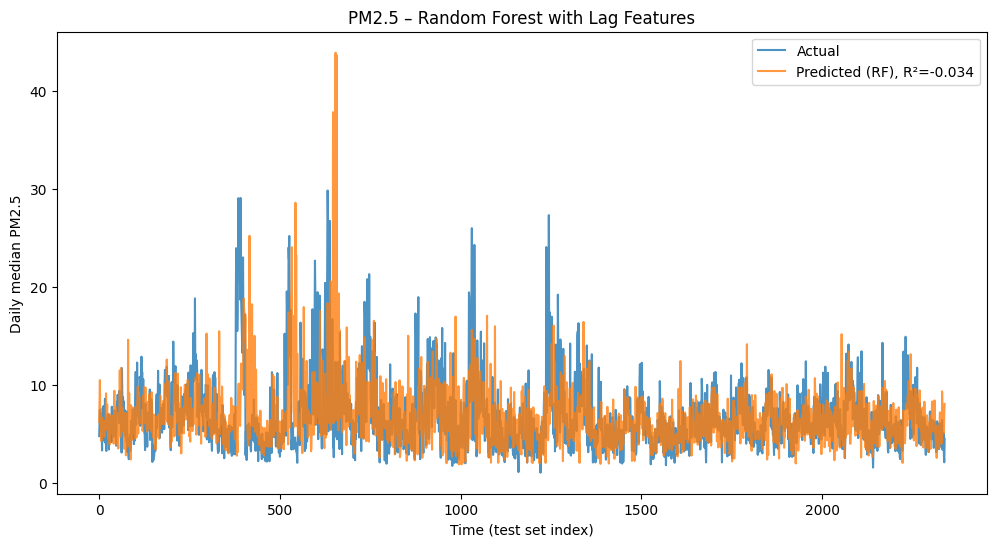

In [52]:
# plot for random forest regressor

plt.figure(figsize=(12, 6))
plt.plot(y_test.values, label="Actual", alpha=0.8)
plt.plot(pred_rf, label=f"Predicted (RF), R²={r2_rf:.3f}", alpha=0.8)
plt.legend()
plt.title("PM2.5 – Random Forest with Lag Features")
plt.xlabel("Time (test set index)")
plt.ylabel("Daily median PM2.5")
plt.show()

In [53]:
# comparing metrics side by side
metrics_df = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_lr, mae_rf],
    "RMSE": [rmse_lr, rmse_rf],
    "R2": [r2_lr, r2_rf],
})

metrics_df

,model,MAE,RMSE,R2
0,Linear Regression,2.635623,3.761971,-0.027415
1,Random Forest,2.335867,3.774590,-0.034320


In [54]:
# Feature importance for random forest
feat_importance_rf = pd.DataFrame({
    "feature": feature_cols,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feat_importance_rf.head(15)

,feature,importance
2,norm_median,0.350541
16,delta_abs_lag1,0.215869
4,daily_median_lag1,0.177296
18,delta_abs_lag3,0.054339
3,doy,0.041913
6,daily_median_lag3,0.037683
13,norm_median_lag1,0.021575
0,roll7,0.018848
5,daily_median_lag2,0.013653
17,delta_abs_lag2,0.012283


In [55]:
coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "coef": lr.coef_
}).sort_values("coef", ascending=False)

coef_df

,feature,coef
1,roll30,5.348018
11,roll30_lag2,1.416220
2,norm_median,1.090908
9,roll7_lag3,0.365654
4,daily_median_lag1,0.248807
8,roll7_lag2,0.239003
0,roll7,0.217346
16,delta_abs_lag1,0.152890
12,roll30_lag3,0.132599
13,norm_median_lag1,0.095917
